In [2]:
import numpy as np
import matplotlib.pyplot as plt

import lightweaver as lw
import promweaver as pw

import astropy.constants as const
from tqdm import tqdm
from matplotlib.colors import LogNorm
from astropy.io import fits

In [28]:
default_ctx = pw.compute_falc_bc_ctx(active_atoms=["H", "Ca"], prd=True, Nthreads=6)
default_ctx.depthData.fill = True
default_ctx.formal_sol_gamma_matrices()

wave = np.linspace(392.8,394.8,1001)
I_prd, susi_ctx = default_ctx.compute_rays(wavelengths=wave, mus=0.05, returnCtx=True)
susi_ctx.depthData.fill = True
susi_ctx.formal_sol_gamma_matrices()
spec_test = fits.PrimaryHDU(I)
ll_test = fits.ImageHDU(wave)
test_hdu = fits.HDUList([spec_test, ll_test])
test_hdu.writeto("disk_center_test.fits", overwrite=True)

        # But this one also needs to spit out the opacities and emissivities for understanding the source function structuring: 
opem = np.zeros((2, len(susi_ctx.atmos.z), len(wave)))
opem[0] = np.copy(susi_ctx.depthData.chi[:,0,0,::-1].T)
opem[1] = np.copy(susi_ctx.depthData.eta[:,0,0,::-1].T)
z = np.copy(susi_ctx.atmos.z[::-1])

opem_hdu = fits.PrimaryHDU(opem)
z_hdu = fits.ImageHDU(z)
opem_cube = fits.HDUList([opem_hdu, z_hdu])
opem_cube.writeto("disk_center_test_opem.fits", overwrite=True)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 5:
dJ = 2.67e+01
    H delta = 8.3996e-01
    Ca delta = 4.3379e-01
    PRD dRho = 1.35e-01, (sub-iterations: 3)
-- Iteration 12:
dJ = 4.65e-01
    H delta = 1.7117e-01
    Ca delta = 1.4113e-01
    PRD dRho = 9.35e-02, (sub-iterations: 3)
-- Iteration 19:
dJ = 1.03e-01
    H delta = 7.0887e-02
    Ca delta = 6.4225e-02
    PRD dRho = 2.61e-02, (sub-iterations: 3)
-- Iteration 26:
dJ = 6.22e-02
    H delta = 4.5414e-02
    Ca delta = 3.5914e-02
    PRD dRho = 1.24e-02, (sub-iterations: 3)
-- Iteration 33:
dJ = 5.33e-02
    H delta = 3.9814e-02
    Ca delta = 2.4473e-02
    PRD dRho = 9.46e-03, (sub-iterations: 3)
-- Iteration 40:
dJ = 4.88e-02
    H delta = 3.4655e-02
    Ca delta = 1.8538e-02
    PRD dRho = 7.68e-03, (sub-iterations: 3)
-- Iteration 47:
dJ = 4.49e-02
    H delta = 2.8269e-02
    Ca delta = 1.4182e-02
    PRD dRho = 6.25e-03, (sub-iterations: 3)
-- Iteration 54:
dJ = 3.98e-02
    H delta = 2.2

In [22]:
op_line = opem[0] - opem[0,-1]
em_line = opem[1] - opem[1,-1]

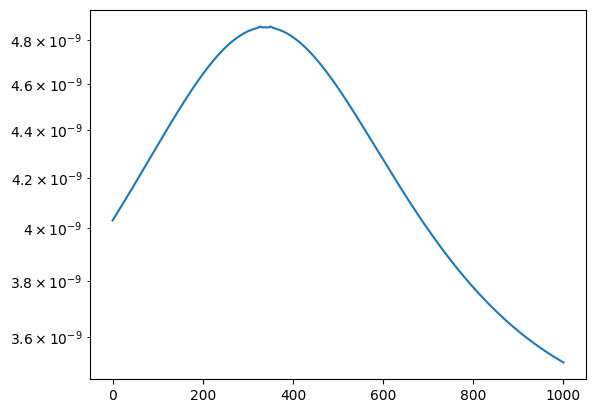

In [24]:
plt.semilogy(em_line[40]/op_line[40], label="line S")

In [15]:
line_core = np.argmax(op_line[30])
print(line_core)

339


/tmp/ipykernel_1260303/3341482351.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(em_line[:,line_core]/op_line[:,line_core], label="line S")


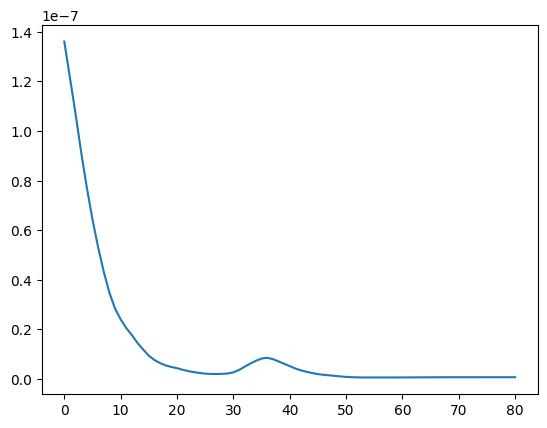

In [16]:
plt.plot(em_line[:,line_core]/op_line[:,line_core], label="line S")

In [29]:
I_crd.shape

(1001,)

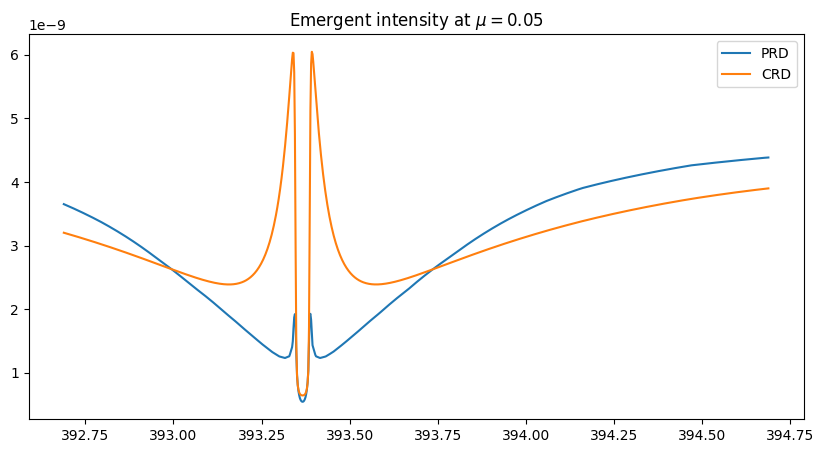

In [35]:
plt.figure(figsize=(10,5))
plt.plot(lw.vac_to_air(wave), I_prd[:], label="PRD")
plt.plot(lw.vac_to_air(wave), I_crd[:], label="CRD")
plt.title("Emergent intensity at $\\mu=0.05$")
plt.legend()
plt.savefig("disk_center_test_s_prd.png", dpi=300,bbox_inches="tight")